In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import json

folder = Path(".") / "grids" / "svhn"
target_metric = "validation_ce_loss"
train_target_metric = target_metric.removeprefix("validation_")

dfs = []

for ent in folder.iterdir():
    
    if not ent.name.endswith(".json"):
        continue

    with open(ent, "r") as f:
        data = json.load(f)


    
    args = ent.stem.split("_")[:-1]
    specs = {}
    for i in range(0, len(args), 2):
        specs[args[i]] = int(args[i + 1])


    df = pd.DataFrame(data)
    df["epoch"] = np.arange(len(df))
    df["run"] = ent.stem
    for k, v in specs.items():
        df[f"{k}_param"] = v
        
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
del dfs

assert df.groupby("run")["epoch"].max().unique().size == 1
df_last_epoch: pd.DataFrame = df[df["epoch"] == df["epoch"].max()]

df.sample(3)

,validation_loss,validation_accuracy_metric,validation_ce_loss,validation_div_loss,validation_kl_fig2,validation_load_distribution_loss,validation_power_entropy_fig1,validation_prediction_entropy_fig1,loss,ce_loss,div_loss,load_distribution_loss,epoch,run,predictors_param,delegators_param,pwidth_param,dwidth_param
857,1.654053,0.662109,1.653989,-0.0,3.044643,0.000064,0.998620,0.319649,1.670534,1.669956,0.0,0.000577,7,predictors_2_delegators_8_pwidth_64_dwidth_4_m...,2,8,64,4
9282,0.967576,0.814063,0.967541,-0.0,5.850358,0.000035,0.754619,0.214103,0.810038,0.810003,0.0,0.000035,32,predictors_64_delegators_1_pwidth_64_dwidth_32...,64,1,64,32
200,2.778825,0.323438,2.778548,-0.0,2.289734,0.000276,0.629005,0.463140,3.148150,3.147957,0.0,0.000193,0,predictors_64_delegators_2_pwidth_64_dwidth_32...,64,2,64,32


<Axes: xlabel='predictors_param', ylabel='validation_mse_loss'>

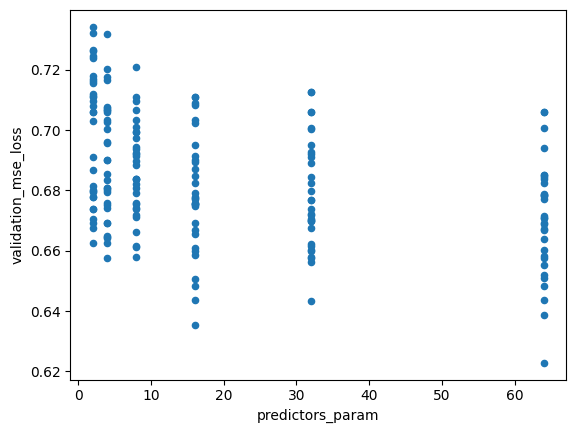

In [ ]:
df_last_epoch.plot.scatter("predictors_param", target_metric)

<Axes: xlabel='delegators_param', ylabel='validation_mse_loss'>

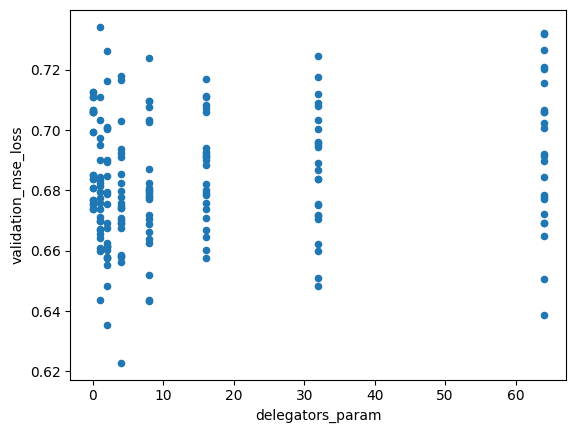

In [51]:
df_last_epoch.plot.scatter("delegators_param", target_metric)

<Axes: xlabel='pwidth_param', ylabel='validation_mse_loss'>

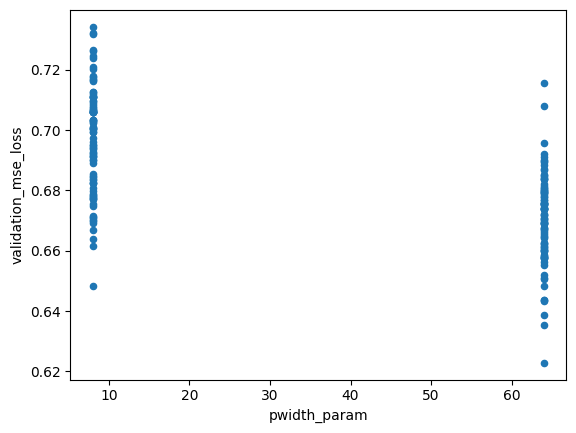

In [53]:
df_last_epoch.plot.scatter("pwidth_param", target_metric)

<Axes: xlabel='dwidth_param', ylabel='validation_mse_loss'>

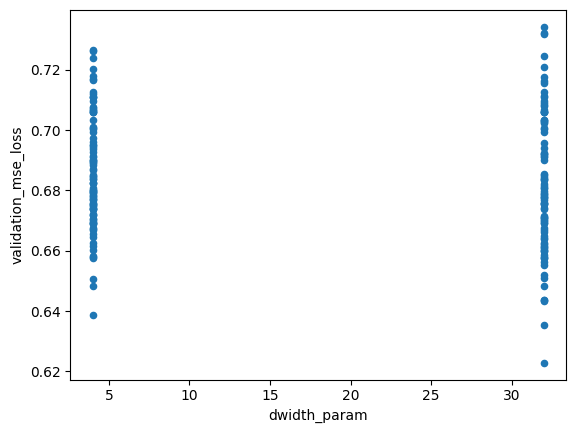

In [54]:
df_last_epoch.plot.scatter("dwidth_param", target_metric)

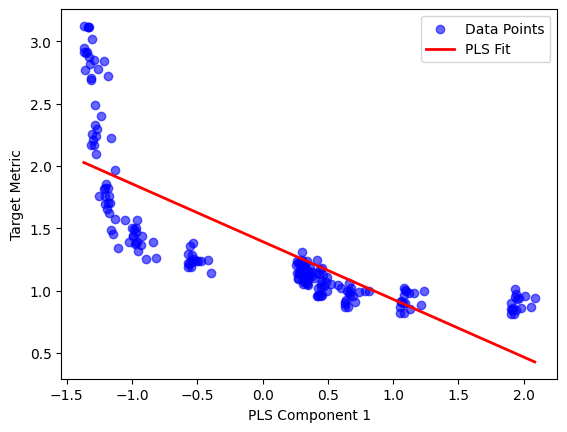

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cross_decomposition import PLSRegression

params_col = df_last_epoch.columns[df_last_epoch.columns.str.endswith("_param")]

X = df_last_epoch[params_col].to_numpy()
y = df_last_epoch[target_metric]
pls = PLSRegression(n_components=1)
X_reduced = pls.fit_transform(X, y)[0]

feature_importance = pls.x_weights_.flatten()
plt.scatter(X_reduced, y, color='blue', alpha=0.6, label="Data Points")
sort_idx = np.argsort(X_reduced.flatten())
plt.plot(X_reduced[sort_idx], pls.predict(X)[sort_idx], color='red', linewidth=2, label="PLS Fit")

plt.xlabel('PLS Component 1')
plt.ylabel('Target Metric')
plt.legend()
plt.show()

In [18]:
feature_importance

array([0.57500707, 0.05083508, 0.81645513, 0.01355291])

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

df_last_epoch['pwidth_cat'] = df_last_epoch['pwidth_param'].astype(str)
df_last_epoch['predictors_cat'] = df_last_epoch['predictors_param'].astype(str)

sns.set_theme(font_scale=3.0, style="ticks")

g = sns.lmplot(
    data=df_last_epoch, 
    x='delegators_param', 
    y=target_metric, 
    col='predictors_cat', 
    row='pwidth_cat',
    height=12,       
    aspect=1.5,     
    scatter_kws={'alpha':0.6, 's': 150}, 
    line_kws={'color': 'red', 'linewidth': 6}
)

g.fig.tight_layout()

# Save as a massive file. Open this file directly from your file manager.
g.savefig("massive_plot.png", dpi=200, bbox_inches='tight')
print("DONE. Open 'massive_plot.png' directly from your file system to view it full size.")

DONE. Open 'massive_plot.png' directly from your file system to view it full size.


In [80]:
params_col

Index(['predictors_param', 'delegators_param', 'pwidth_param', 'dwidth_param'], dtype='str')

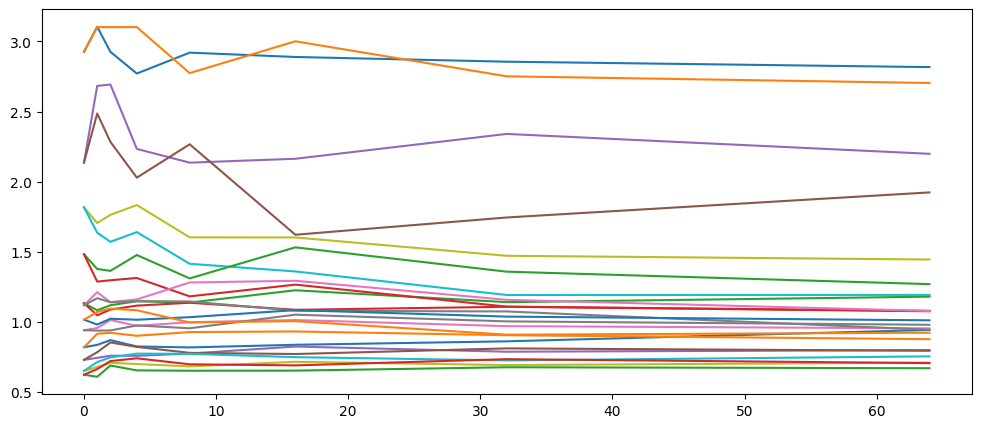

In [20]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for _, sub in df_last_epoch.groupby(["predictors_param", "pwidth_param", "dwidth_param"]):

    sub = sub.sort_values("delegators_param")

    ax.plot(sub["delegators_param"], sub[train_target_metric])


<Axes: ylabel='Frequency'>

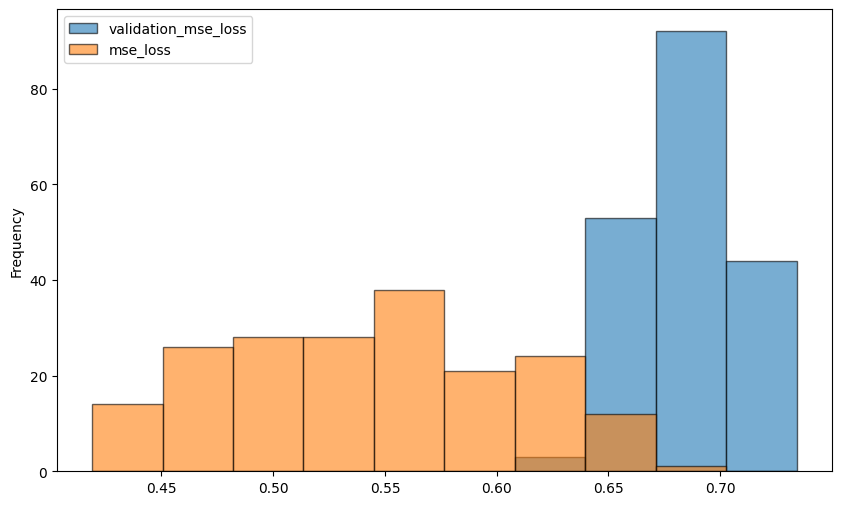

In [10]:
df_last_epoch[["validation_mse_loss", "mse_loss"]].plot.hist(alpha=0.6, figsize=(10, 6), edgecolor="black")